# High-freq bouts — clean computational pipeline

Mirror of `alarm_bouts_2.ipynb` but for `event_type == "high-freq"`.
Top half builds reusable DataFrames once; later cells slice them.

After the load + bout-detection cell, every row in `hf` carries:
- `bout_id` — unique per consecutive run within `(date_folder, exp, assigned_location)`, gap ≤ `ICI_HIGH_FREQ_BOUT_THRESHOLD_S`.
- `bout_size` — total calls in that bout (broadcast to every row).
- `position` — chronological position within the bout (1 = first call).

## Setup

In [8]:
# === Cell: setup ===
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PARQUET_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")
FIGURES_DIR  = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures/high_freq")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]
# Bout-defining ICI range. A pair of consecutive calls counts as "same bout"
# only if their gap is in [MIN_ICI_BOUT_S, MAX_ICI_BOUT_S]. Sub-MIN gaps are
# probably artifacts (overlap from two animals, or one call split in two);
# above MAX is a between-bout silence.
MIN_ICI_BOUT_S = 0.05   
MAX_ICI_BOUT_S = 0.2    # 200 ms — empirical dip after the 100 ms mode
ICI_HIGH_FREQ_BOUT_THRESHOLD_S = MAX_ICI_BOUT_S   # backwards-compat alias
MIN_BOUT_SIZE = 3                      # bouts_meta keeps only bouts with >= this many calls

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")

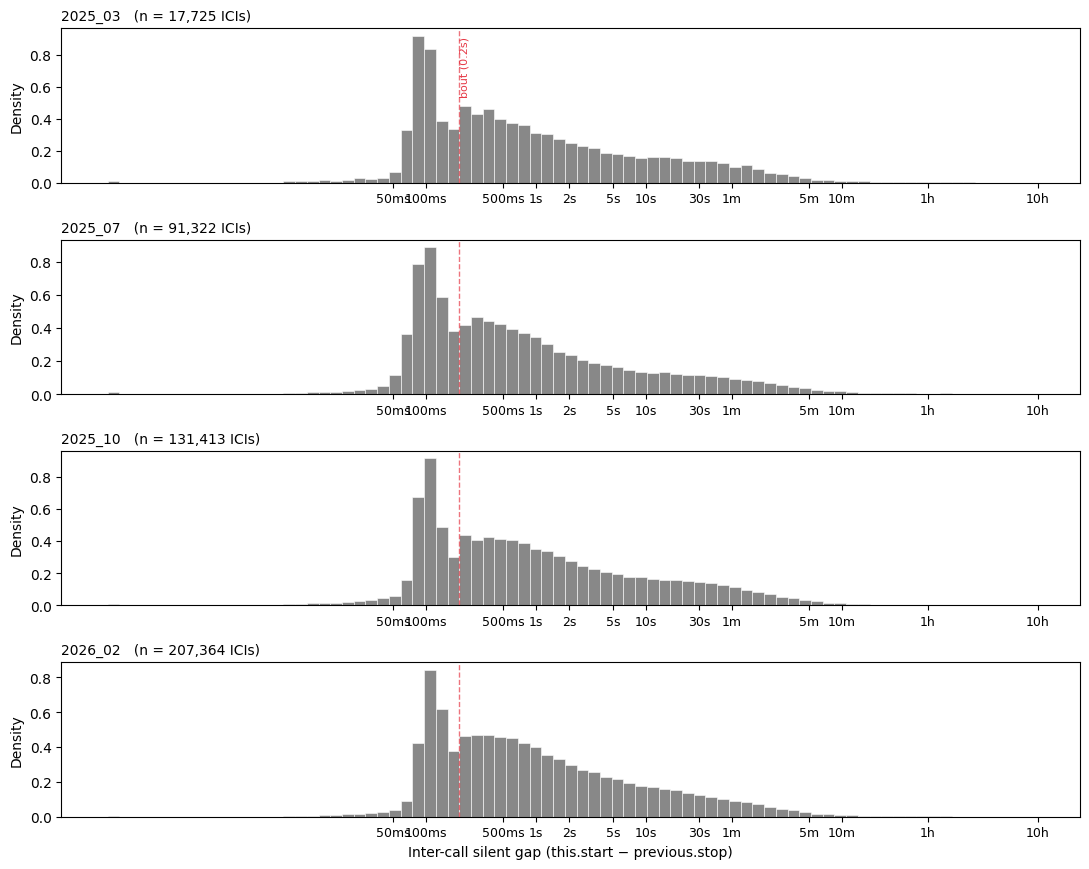

In [ ]:
# High freq only
# === Cell: plot_ici_distribution_per_date ===
prev_stop = hf.groupby(
    ["date_folder", "exp", "assigned_location"]
)["stop_time_real"].shift(1)
hf_ici = pd.DataFrame({
    "date_folder": hf["date_folder"],
    "ici_s":       (hf["start_time_real"] - prev_stop).dt.total_seconds(),
}).dropna()
hf_ici = hf_ici[hf_ici["ici_s"] > 0]

# Shared log-bins so panels are comparable.
log_ici_all = np.log10(hf_ici["ici_s"])
bins = np.linspace(log_ici_all.min(), log_ici_all.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = hf_ici[hf_ici["date_folder"] == date_tag]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no ICIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    log_sub = np.log10(sub["ici_s"])
    ax.hist(log_sub, bins=bins, density=True, color="#888888",
            edgecolor="white", linewidth=0.4)

    ax.axvline(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), color="#E63946",
               linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} ICIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.tick_params(labelbottom=True)

# Tick labels on every panel.
tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h", "10h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[0].text(np.log10(ICI_HIGH_FREQ_BOUT_THRESHOLD_S), axes[0].get_ylim()[1] * 0.95,
             f"  bout ({ICI_HIGH_FREQ_BOUT_THRESHOLD_S}s)",
             rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Inter-call silent gap (this.start − previous.stop)")
fig.tight_layout()
save_fig(fig, "high_freq_ici_distribution_per_date")
plt.show()

## high freq with warbles



In [9]:
# === Cell: prep_merged_hf_warble_bouts ===
# 1) Load HF + warble together.
parts = []
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d = df_d[df_d["event_type"].isin(["high-freq", "warble"])]
    parts.append(df_d)
hf_w = pd.concat(parts, ignore_index=True)

# 2) Sort within (date, exp, location), compute per-call silent gap.
hf_w = hf_w.sort_values(
    ["date_folder", "exp", "assigned_location", "start_time_real"]
).reset_index(drop=True)

grp = hf_w.groupby(["date_folder", "exp", "assigned_location"])
prev_stop  = grp["stop_time_real"].shift(1)
prev_start = grp["start_time_real"].shift(1)

# Two flavors of inter-call interval:
#   ici_s        — silent gap (this.start - prev.stop). Bout-detection threshold.
#   ici_period_s — start-to-start period (this.start - prev.start). 1/period = Hz.
hf_w["ici_s"]        = (hf_w["start_time_real"] - prev_stop ).dt.total_seconds()
hf_w["ici_period_s"] = (hf_w["start_time_real"] - prev_start).dt.total_seconds()

# 3) Define merged bouts: gap must be in [MIN_ICI_BOUT_S, MAX_ICI_BOUT_S]
#    to count as same-bout. Outside that range starts a new bout.
is_new_bout = (
    hf_w["ici_s"].isna()
    | (hf_w["ici_s"] > MAX_ICI_BOUT_S)
    | (hf_w["ici_s"] < MIN_ICI_BOUT_S)
)
hf_w["merged_bout_id"] = is_new_bout.cumsum()

# 4) Per-bout summary.
merged_bouts = hf_w.groupby("merged_bout_id").agg(
    date_folder=("date_folder", "first"),
    n_calls=("event_type", "size"),
    n_hf=("event_type", lambda s: (s == "high-freq").sum()),
    n_w=("event_type",  lambda s: (s == "warble").sum()),
)
merged_bouts["frac_hf"] = merged_bouts["n_hf"] / merged_bouts["n_calls"]

print(f"{len(hf_w):,} HF+W calls, {len(merged_bouts):,} merged bouts "
      f"({(merged_bouts['n_calls'] >= MIN_BOUT_SIZE).sum():,} with >= {MIN_BOUT_SIZE} calls)")

1,123,318 HF+W calls, 754,175 merged bouts (78,410 with >= 3 calls)


In [10]:
# === Cell: categorize_bouts_hf_vs_warble ===
# Three categories based on call composition:
#   hf         — frac_hf == 1.0  (all calls are high-freq)
#   warble     — frac_hf == 0.0  (all calls are warble)
#   hf_warble  — 0 < frac_hf < 1 (mixed)
# frac_hf stays on merged_bouts/bouts so finer thresholds are still possible.
merged_bouts["category"] = np.where(
    merged_bouts["frac_hf"] == 1.0, "hf",
    np.where(merged_bouts["frac_hf"] == 0.0, "warble", "hf_warble"),
)

# One row per multi-call merged bout 
bouts = merged_bouts[merged_bouts["n_calls"] >= MIN_BOUT_SIZE].copy()

# Map category back to per-call rows.
hf_w["bout_category"] = hf_w["merged_bout_id"].map(merged_bouts["category"])

print(f"{len(bouts):,} multi-call bouts (>= {MIN_BOUT_SIZE} calls)")
print()
print("By category:")
print(bouts["category"].value_counts())
print()
print("Per-date breakdown:")
print(bouts.groupby(["date_folder", "category"]).size().unstack(fill_value=0))

78,410 multi-call bouts (>= 3 calls)

By category:
category
hf_warble    36103
warble       23737
hf           18570
Name: count, dtype: int64

Per-date breakdown:
category       hf  hf_warble  warble
date_folder                         
2025_03       788       1130     509
2025_07      4947       5975    4762
2025_10      5579       9846    5525
2026_02      7256      19152   12941


## Within-bout ICI: HF vs warble category

Per-date overlay of within-bout ICI density for HF-containing bouts vs pure
warble bouts.

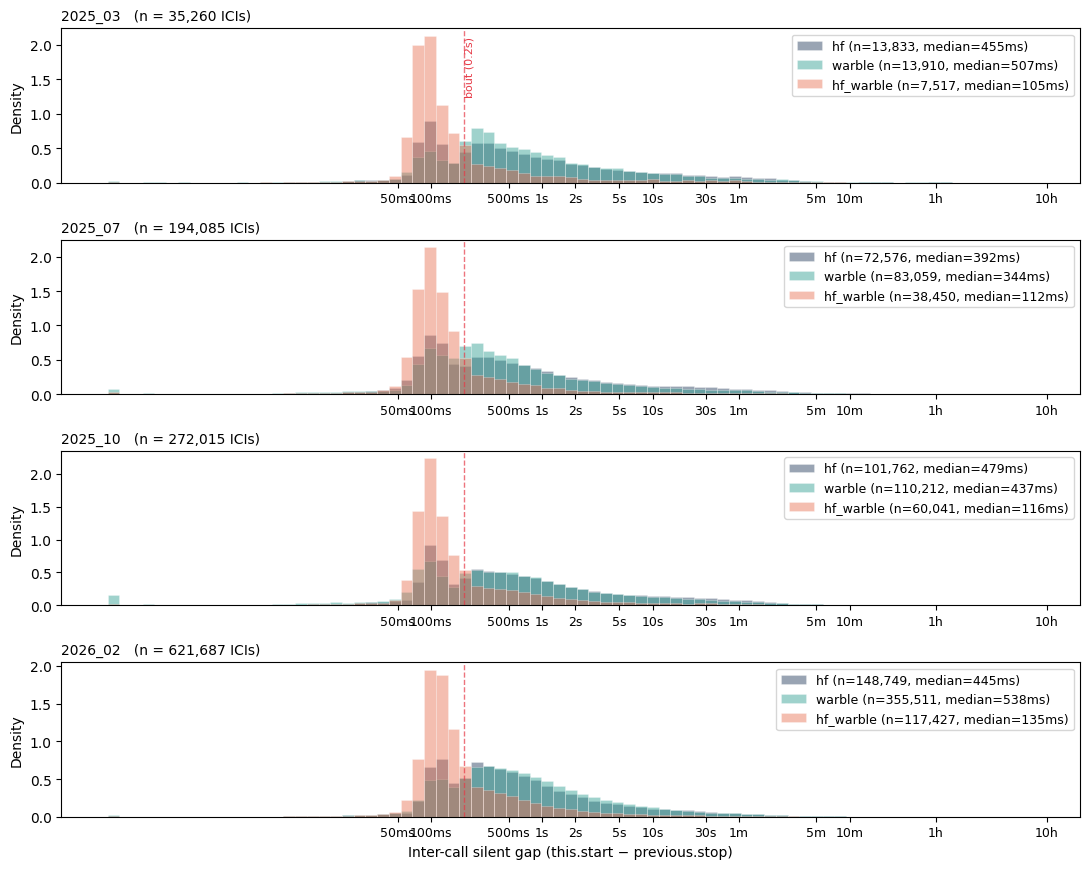

In [11]:
# === Cell: plot_within_bout_ici_hf_vs_warble ===
# All inter-call silent gaps (no cap), tagged by the category of the bout
# the *current* call belongs to. The MAX_ICI_BOUT_S threshold is shown as a
# vertical line — gaps above it are bout boundaries by definition.
gaps = hf_w[hf_w["ici_s"].notna() & (hf_w["ici_s"] > 0)]

CATEGORIES = [
    ("hf",        "#1D3557"),
    ("warble",    "#2A9D8F"),
    ("hf_warble", "#E76F51"),
]

# Shared log-bins so panels are comparable. 80 bins matches the stale plot.
log_ici = np.log10(gaps["ici_s"])
bins = np.linspace(log_ici.min(), log_ici.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = gaps[gaps["date_folder"] == date_tag]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no ICIs",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    for cat, color in CATEGORIES:
        s = sub[sub["bout_category"] == cat]["ici_s"]
        if s.empty:
            continue
        ax.hist(np.log10(s), bins=bins, density=True,
                color=color, edgecolor="white", linewidth=0.4, alpha=0.45,
                label=f"{cat} (n={len(s):,}, median={s.median()*1000:.0f}ms)")

    ax.axvline(np.log10(MAX_ICI_BOUT_S), color="#E63946",
               linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} ICIs)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(labelbottom=True)

# Tick labels span the full range, like the stale plot.
tick_seconds = [0.05, 0.1, 0.5, 1, 2, 5, 10, 30, 60, 300, 600, 3600, 36000]
tick_labels  = ["50ms", "100ms", "500ms", "1s", "2s", "5s", "10s", "30s",
                "1m", "5m", "10m", "1h", "10h"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=9)

axes[0].text(np.log10(MAX_ICI_BOUT_S), axes[0].get_ylim()[1] * 0.95,
             f"  bout ({MAX_ICI_BOUT_S}s)",
             rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Inter-call silent gap (this.start − previous.stop)")
fig.tight_layout()
save_fig(fig, "all_ici_hf_vs_warble_per_date")
plt.show()

## Within-bout calling rate (period → Hz)

Same data as the within-bout ICI plot, but in **start-to-start period**
units. `1 / median(period) = within-bout calling rate in Hz` — the right
number to quote in the abstract.

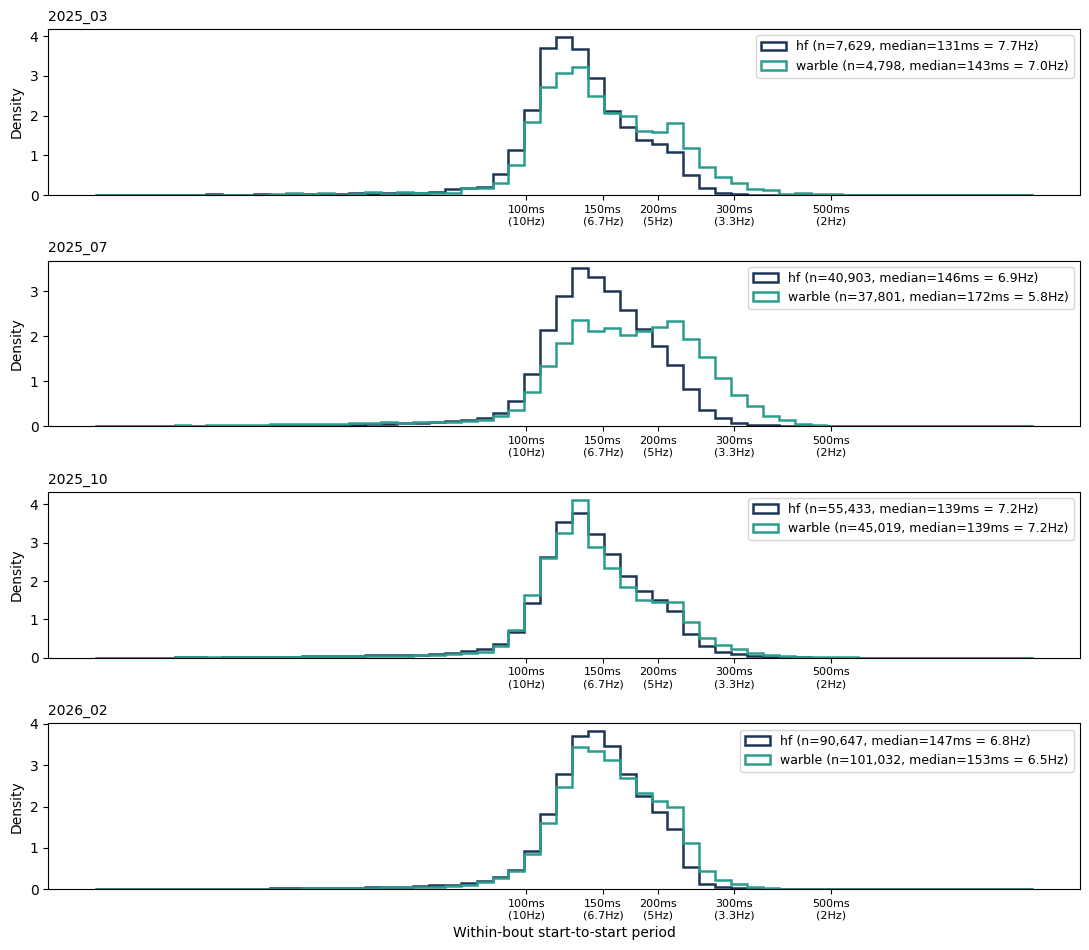


=== Median within-bout rate (start-to-start period) ===
date_folder category      n  median_period_s  median_rate_hz
    2025_03       hf   7629            0.131            7.65
    2025_03   warble   4798            0.143            7.01
    2025_07       hf  40903            0.146            6.87
    2025_07   warble  37801            0.172            5.82
    2025_10       hf  55433            0.139            7.21
    2025_10   warble  45019            0.139            7.21
    2026_02       hf  90647            0.147            6.80
    2026_02   warble 101032            0.153            6.55


In [7]:
# === Cell: plot_within_bout_period_hf_vs_warble ===
# Within-bout periods (start-to-start) in multi-call merged bouts, by category.
# Visual style matches the stale per-date HF-only ICI plot (cell 3).
within = hf_w[
    hf_w["merged_bout_id"].isin(bouts.index)
    & hf_w["ici_s"].notna()
    & (hf_w["ici_s"] > 0)
    & (hf_w["ici_s"] <= MAX_ICI_BOUT_S)
    & (hf_w["ici_period_s"] > 0)
]

CATEGORIES = [
    ("hf",        "#1D3557"),
    ("warble",    "#2A9D8F"),
    ("hf_warble", "#E76F51"),
]

# Shared log-bins so panels are comparable. 80 bins matches the stale plot.
log_p = np.log10(within["ici_period_s"])
bins = np.linspace(log_p.min(), log_p.max(), 80)

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.2 * len(DATES_TO_PLOT)),
    sharex=True, sharey=False,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

summary_rows = []
for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = within[within["date_folder"] == date_tag]
    if sub.empty:
        ax.text(0.5, 0.5, f"{date_tag}: no periods",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue
    for cat, color in CATEGORIES:
        s = sub[sub["bout_category"] == cat]["ici_period_s"]
        if s.empty:
            continue
        med_s  = s.median()
        med_hz = 1.0 / med_s
        summary_rows.append({"date_folder": date_tag, "category": cat,
                             "n": len(s), "median_period_s": round(med_s, 3),
                             "median_rate_hz": round(med_hz, 2)})
        ax.hist(np.log10(s), bins=bins, density=True,
                color=color, edgecolor="white", linewidth=0.4, alpha=0.45,
                label=f"{cat} (n={len(s):,}, median={med_s*1000:.0f}ms = {med_hz:.1f}Hz)")

    ax.axvline(np.log10(MAX_ICI_BOUT_S), color="#E63946",
               linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_title(f"{date_tag}   (n = {len(sub):,} periods)", loc="left", fontsize=10)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9, loc="upper right")
    ax.tick_params(labelbottom=True)

tick_seconds = [0.1, 0.15, 0.2, 0.3, 0.5]
tick_labels  = ["100ms\n(10Hz)", "150ms\n(6.7Hz)", "200ms\n(5Hz)",
                "300ms\n(3.3Hz)", "500ms\n(2Hz)"]
for ax in axes:
    ax.set_xticks(np.log10(tick_seconds))
    ax.set_xticklabels(tick_labels, fontsize=8)

axes[0].text(np.log10(MAX_ICI_BOUT_S), axes[0].get_ylim()[1] * 0.95,
             f"  bout gap ({MAX_ICI_BOUT_S}s)",
             rotation=90, fontsize=8, color="#E63946", va="top")

axes[-1].set_xlabel("Within-bout start-to-start period (this.start − previous.start)")
fig.tight_layout()
save_fig(fig, "within_bout_period_hf_vs_warble_per_date")
plt.show()

print()
print("=== Median within-bout rate (start-to-start period) ===")
print(pd.DataFrame(summary_rows).to_string(index=False))

## Bout-size distribution: HF vs warble category

Per-date overlay of the number-of-calls-per-bout distribution for HF bouts
vs warble bouts.

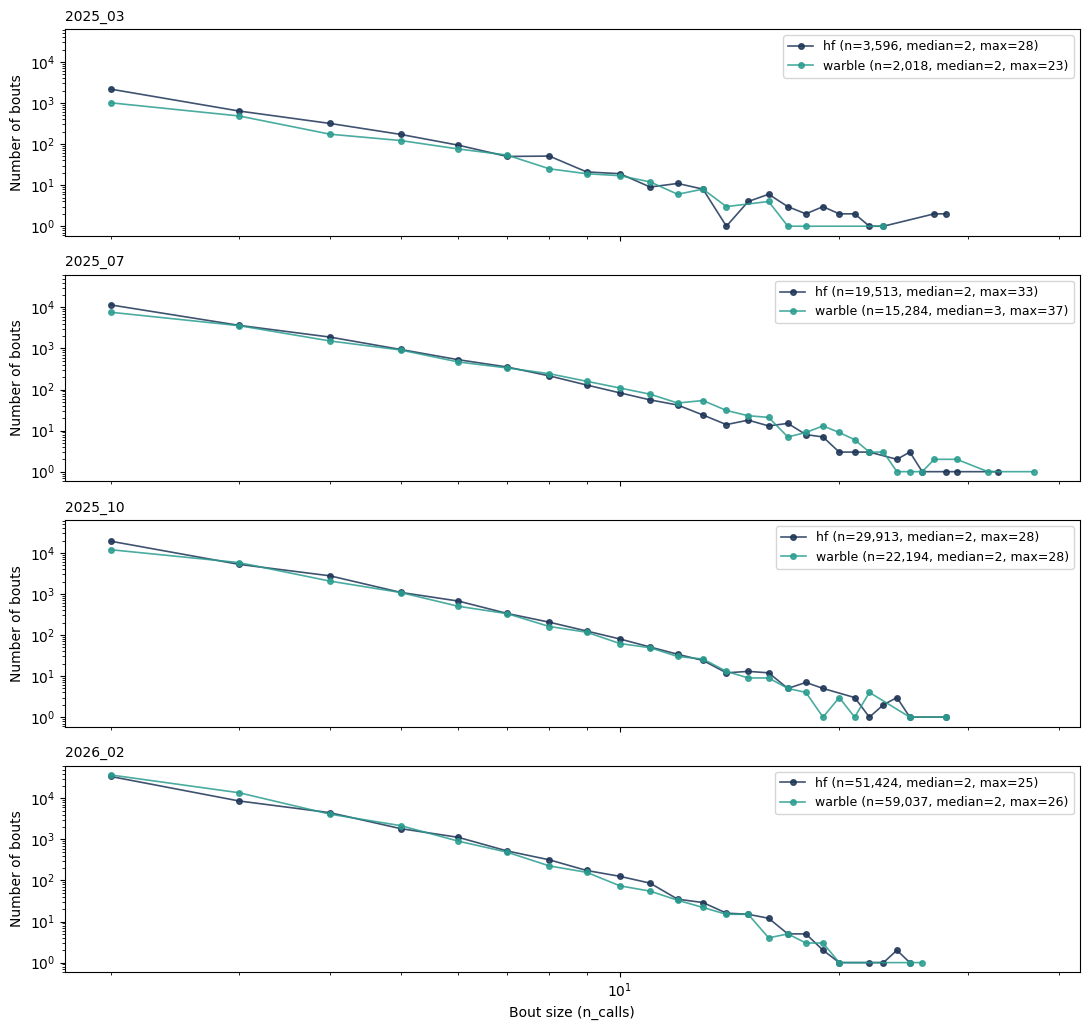

In [8]:
# === Cell: plot_bout_size_hf_vs_warble ===
CATEGORIES = [
    ("hf",        "#1D3557"),
    ("warble",    "#2A9D8F"),
    ("hf_warble", "#E76F51"),
]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(11, 2.6 * len(DATES_TO_PLOT)),
    sharex=True, sharey=True,
)
if len(DATES_TO_PLOT) == 1:
    axes = [axes]

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    sub = bouts[bouts["date_folder"] == date_tag]
    if sub.empty:
        ax.set_axis_off()
        continue
    for cat, color in CATEGORIES:
        s = sub[sub["category"] == cat]["n_calls"]
        if s.empty:
            continue
        sizes = s.value_counts().sort_index()
        ax.plot(sizes.index, sizes.values, marker="o", linestyle="-",
                color=color, alpha=0.85, markersize=4, linewidth=1.2,
                label=f"{cat} (n={len(s):,}, median={s.median():.0f}, max={s.max()})")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(date_tag, loc="left", fontsize=10)
    ax.set_ylabel("Number of bouts")
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Bout size (n_calls)")
fig.tight_layout()
save_fig(fig, "bout_size_hf_vs_warble_per_date")
plt.show()

## `bouts_meta` — one row per bout

In [9]:
# === Cell: build_bouts_meta ===
# One row per multi-call merged bout. Indexed by merged_bout_id.
# Three category-specific dataframes plus the unified bouts_meta.

# Position within each merged bout (1 = first call).
hf_w["position"] = hf_w.groupby("merged_bout_id").cumcount() + 1

bouts_meta = (
    hf_w[hf_w["position"] == 1]
    .set_index("merged_bout_id")
    [[
        "date_folder", "exp", "file_num", "assigned_location",
        "start_time_real", "start_time_file_sec",
        "start_time_experiment_sec", "day_in_experiment",
    ]]
    .join(bouts[["n_calls", "n_hf", "n_w", "frac_hf", "category"]], how="inner")
    .rename(columns={"n_calls": "bout_size"})
)

bouts_meta_hf        = bouts_meta[bouts_meta["category"] == "hf"].copy()
bouts_meta_warble    = bouts_meta[bouts_meta["category"] == "warble"].copy()
bouts_meta_hf_warble = bouts_meta[bouts_meta["category"] == "hf_warble"].copy()

print(f"bouts_meta_hf:        {len(bouts_meta_hf):,} bouts")
print(f"bouts_meta_warble:    {len(bouts_meta_warble):,} bouts")
print(f"bouts_meta_hf_warble: {len(bouts_meta_hf_warble):,} bouts")

bouts_meta_hf:     104,446 bouts
bouts_meta_warble: 98,533 bouts


## `duration_by_position` — wide-format duration matrix

One row per bout, one column per position, values are call durations (NaN where the bout doesn't have that position). Built once on the full high-freq dataset; per-analysis filtering happens by selecting rows from this matrix.

In [10]:
# === Cell: build_duration_by_position ===
# One duration-by-position matrix per category. Each is indexed by
# merged_bout_id (aligned with the matching bouts_meta_<cat>).

duration_by_position_hf = (
    hf_w[hf_w["merged_bout_id"].isin(bouts_meta_hf.index)]
    .pivot(index="merged_bout_id", columns="position", values="duration_sec")
)
duration_by_position_warble = (
    hf_w[hf_w["merged_bout_id"].isin(bouts_meta_warble.index)]
    .pivot(index="merged_bout_id", columns="position", values="duration_sec")
)
duration_by_position_hf_warble = (
    hf_w[hf_w["merged_bout_id"].isin(bouts_meta_hf_warble.index)]
    .pivot(index="merged_bout_id", columns="position", values="duration_sec")
)
print(f"duration_by_position_hf:        {duration_by_position_hf.shape[0]:,} × {duration_by_position_hf.shape[1]}")
print(f"duration_by_position_warble:    {duration_by_position_warble.shape[0]:,} × {duration_by_position_warble.shape[1]}")
print(f"duration_by_position_hf_warble: {duration_by_position_hf_warble.shape[0]:,} × {duration_by_position_hf_warble.shape[1]}")

duration_by_position_hf:     104,446 × 33
duration_by_position_warble: 98,533 × 37


## Call duration by position

Violin plots of call duration at each position in the bout, separately for HF
and warble category bouts. Later positions are computed over the smaller
subset of bouts that reach that length.

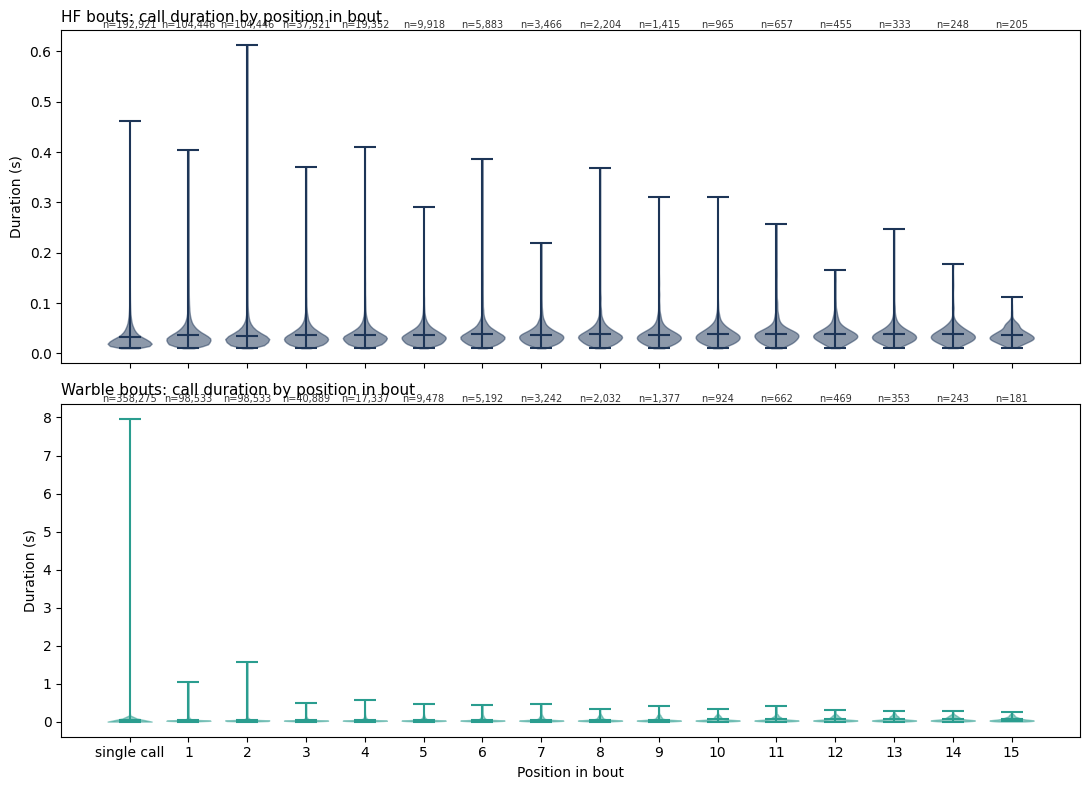

In [11]:
# === Cell: plot_duration_by_position_violin ===
MAX_POS = 15

# Singleton durations (1-call merged bouts, by event_type). No hf_warble singletons.
_n_calls = hf_w["merged_bout_id"].map(merged_bouts["n_calls"])
hf_singletons     = hf_w.loc[(_n_calls == 1) & (hf_w["event_type"] == "high-freq"), "duration_sec"].values
warble_singletons = hf_w.loc[(_n_calls == 1) & (hf_w["event_type"] == "warble"),    "duration_sec"].values

# Per-panel max-duration cap (None = no cap). Warble has occasional ~8 s
# outliers — almost certainly mis-segmented. Clip them out of the plot.
PANELS = [
    (duration_by_position_hf,        hf_singletons,     "HF bouts",        "#1D3557", None),
    (duration_by_position_warble,    warble_singletons, "Warble bouts",    "#2A9D8F", 1.0),
    (duration_by_position_hf_warble, None,              "HF+Warble bouts", "#E76F51", None),
]

fig, axes = plt.subplots(len(PANELS), 1, figsize=(11, 4 * len(PANELS)), sharex=True)
if len(PANELS) == 1:
    axes = [axes]

for ax, (dbp, singletons, label, color, max_dur) in zip(axes, PANELS):
    positions, data = [], []
    n_total, n_dropped = 0, 0

    if singletons is not None and len(singletons) >= 5:
        n_total += len(singletons)
        if max_dur is not None:
            n_dropped += int((singletons >= max_dur).sum())
            singletons = singletons[singletons < max_dur]
        if len(singletons) >= 5:
            positions.append(0)
            data.append(singletons)

    for pos in range(MIN_BOUT_SIZE, MAX_POS + 1):
        if pos not in dbp.columns:
            continue
        vals = dbp[pos].dropna().values
        n_total += len(vals)
        if max_dur is not None:
            n_dropped += int((vals >= max_dur).sum())
            vals = vals[vals < max_dur]
        if len(vals) < 5:
            continue
        positions.append(pos)
        data.append(vals)
    if not data:
        ax.set_axis_off()
        continue

    if max_dur is not None:
        pct = (n_dropped / n_total * 100) if n_total else 0.0
        print(f"{label:18s} clipped {n_dropped:,} / {n_total:,} durations >= {max_dur}s ({pct:.3f}%)")

    parts = ax.violinplot(data, positions=positions, showmeans=True, widths=0.75)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor(color)
    for key in ("cbars", "cmins", "cmaxes", "cmeans"):
        if key in parts:
            parts[key].set_color(color)

    y_max = max(v.max() for v in data)
    ax.set_ylim(top=y_max * 1.20)
    y_top = y_max * 1.05
    for pos, vals in zip(positions, data):
        ax.text(pos, y_top, f"n={len(vals):,}", ha="center", va="bottom",
                fontsize=7, color="#333333")

    ax.set_xticks(positions)
    ax.set_xticklabels(["single call" if p == 0 else str(p) for p in positions])
    ax.tick_params(labelbottom=True)
    ax.set_ylabel("Duration (s)")
    title = f"{label}: call duration by position in bout"
    if max_dur is not None:
        title += f"  (durations >= {max_dur}s clipped)"
    ax.set_title(title, loc="left", fontsize=11, pad=12)

axes[-1].set_xlabel("Position in bout (= min calls per bout)")
fig.tight_layout()
fig.subplots_adjust(hspace=0.45)
save_fig(fig, "duration_by_position_violin")
plt.show()

## Same-bouts comparison

Restrict to bouts that contain at least `MAX_POS` calls so every position bar
is computed over the **exact same set of bouts** — eliminates the selection
bias where later positions only sample the longest bouts.

In [ ]:
# === Cell: plot_duration_by_position_violin_constant_bouts ===
MAX_POS = 15

PANELS = [
    (duration_by_position_hf,        "HF bouts",        "#1D3557", None),
    (duration_by_position_warble,    "Warble bouts",    "#2A9D8F", 1.0),
    (duration_by_position_hf_warble, "HF+Warble bouts", "#E76F51", None),
]

fig, axes = plt.subplots(len(PANELS), 1, figsize=(11, 4 * len(PANELS)), sharex=True)
if len(PANELS) == 1:
    axes = [axes]

for ax, (dbp, label, color, max_dur) in zip(axes, PANELS):
    # Bouts with at least MAX_POS calls — i.e., a non-NaN value at every position
    # from MIN_BOUT_SIZE through MAX_POS.
    keep = dbp.dropna(subset=list(range(MIN_BOUT_SIZE, MAX_POS + 1)), how="any")

    positions, data = [], []
    n_total, n_dropped = 0, 0
    for pos in range(MIN_BOUT_SIZE, MAX_POS + 1):
        if pos not in keep.columns:
            continue
        vals = keep[pos].values
        n_total += len(vals)
        if max_dur is not None:
            n_dropped += int((vals >= max_dur).sum())
            vals = vals[vals < max_dur]
        if len(vals) < 5:
            continue
        positions.append(pos)
        data.append(vals)
    if not data:
        ax.text(0.5, 0.5, f"{label}: no bouts with >= {MAX_POS} calls",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if max_dur is not None:
        pct = (n_dropped / n_total * 100) if n_total else 0.0
        print(f"{label:18s} clipped {n_dropped:,} / {n_total:,} durations >= {max_dur}s ({pct:.3f}%)")

    parts = ax.violinplot(data, positions=positions, showmeans=True, widths=0.75)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor(color)
    for key in ("cbars", "cmins", "cmaxes", "cmeans"):
        if key in parts:
            parts[key].set_color(color)

    y_max = max(v.max() for v in data)
    ax.set_ylim(top=y_max * 1.20)
    y_top = y_max * 1.05
    n_bouts = len(keep)
    for pos in positions:
        ax.text(pos, y_top, f"n={n_bouts:,}", ha="center", va="bottom",
                fontsize=7, color="#333333")

    ax.set_xticks(positions)
    ax.set_xticklabels([str(p) for p in positions])
    ax.tick_params(labelbottom=True)
    ax.set_ylabel("Duration (s)")
    title = f"{label}: same {n_bouts:,} bouts (>= {MAX_POS} calls) at every position"
    if max_dur is not None:
        title += f"  (>= {max_dur}s clipped)"
    ax.set_title(title, loc="left", fontsize=11, pad=12)

axes[-1].set_xlabel("Position in bout")
fig.tight_layout()
fig.subplots_adjust(hspace=0.45)
save_fig(fig, "duration_by_position_violin_constant_bouts")
plt.show()